# LAB 05 — HOG-Based Industrial Defect Detection and Classification

**Pipeline:** Image → Preprocessing (grayscale + resize) → HOG feature extraction → ML classifier → DEFECTIVE / NON-DEFECTIVE → ACCEPT / REJECT

**Runtime:** Colab → *Runtime → Change runtime type → T4 GPU*, then *Run all*.

**How it is optimised for the T4**
* HOG is implemented in PyTorch (`hog_torch`) and runs on the GPU in batches (equivalent to `skimage.feature.hog`: gradient → orientation histograms per cell → 2×2 block L2-Hys normalisation, with soft binning). `skimage` is used only for the HOG *visualisations*.
* The SVM Gram matrix is computed on the GPU and solved with libsvm (`KernelSVC`), so the 9-config HOG sweep takes seconds instead of minutes.
* XGBoost (second classifier) runs on the GPU. Robustness perturbations (brightness / noise / rotation / blur) are also GPU ops.

**Important note about the dataset.** NEU-DET contains **only defective images** (6 defect classes: crazing, inclusion, patches, pitted_surface, rolled-in_scale, scratches) — there is no "normal" class. To build the binary task required by the lab, I use the bounding-box annotations:
* **Class 1 (Defective)** = a 64×64 window centred on each annotated defect box.
* **Class 0 (Normal)** = a 64×64 window cropped from a *defect-free* region of the same steel strip (zero overlap with every annotated box).

Both are upscaled to the same 128×128 resolution so that image size/interpolation cannot leak the label. The multi-class (6 defect types) version is also done as the *advanced* task, on full images.

## 0. Setup

In [1]:
!pip install -q kagglehub

import os, re, time, math, random, warnings, json
from pathlib import Path
from functools import partial
import xml.etree.ElementTree as ET
from concurrent.futures import ThreadPoolExecutor

import numpy as np, pandas as pd
import cv2, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
import joblib

from skimage.feature import hog as sk_hog
from skimage import exposure
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU only -> enable a T4 GPU runtime for speed")

OUT = Path("lab05_outputs"); OUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})

Device: cuda | Tesla T4


### GPU HOG + GPU-kernel SVM + decision module (`hog_utils.py`)
This cell writes the helper module to disk (it is also re-used by the real-time script at the end).

In [2]:
%%writefile hog_utils.py
"""HOG + SVM utilities for Lab 05 (GPU accelerated with PyTorch)."""
import math
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.svm import SVC


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def preprocess_gray(img, size=128):
    """BGR/gray uint8 image -> grayscale uint8 (size x size)."""
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    interp = cv2.INTER_AREA if max(img.shape[:2]) > size else cv2.INTER_LINEAR
    return cv2.resize(img, (size, size), interpolation=interp)


def _hog_batch(g, cell, orient, clip, eps):
    """g: (N,H,W) float in [0,1] -> (N, D) HOG features (2x2 blocks, stride 1 cell, L2-Hys)."""
    N, H, W = g.shape
    g = g.unsqueeze(1)
    gp = F.pad(g, (1, 1, 1, 1), mode="replicate")
    gx = gp[:, :, 1:-1, 2:] - gp[:, :, 1:-1, :-2]
    gy = gp[:, :, 2:, 1:-1] - gp[:, :, :-2, 1:-1]
    mag = torch.sqrt(gx * gx + gy * gy)
    ang = torch.atan2(gy, gx) % math.pi                  # unsigned orientation [0, pi)
    pos = ang / math.pi * orient - 0.5                    # soft-binning (linear interpolation)
    lo = torch.floor(pos)
    w_hi = pos - lo
    lo_i = lo.long() % orient
    hi_i = (lo.long() + 1) % orient
    hist = torch.zeros(N, orient, H, W, device=g.device, dtype=g.dtype)
    hist.scatter_add_(1, lo_i, mag * (1 - w_hi))
    hist.scatter_add_(1, hi_i, mag * w_hi)
    Hc, Wc = H // cell, W // cell
    hist = hist[:, :, : Hc * cell, : Wc * cell]
    cells = F.avg_pool2d(hist, cell, cell) * (cell * cell)   # (N, O, Hc, Wc) sum per cell
    blocks = torch.stack(
        [cells[:, :, :-1, :-1], cells[:, :, :-1, 1:], cells[:, :, 1:, :-1], cells[:, :, 1:, 1:]], dim=2
    )                                                      # (N, O, 4, Hc-1, Wc-1)
    blocks = blocks.permute(0, 3, 4, 2, 1).reshape(N, Hc - 1, Wc - 1, 4 * orient)
    blocks = blocks / torch.sqrt((blocks ** 2).sum(-1, keepdim=True) + eps ** 2)
    blocks = blocks.clamp(max=clip)
    blocks = blocks / torch.sqrt((blocks ** 2).sum(-1, keepdim=True) + eps ** 2)
    return blocks.reshape(N, -1)


@torch.no_grad()
def hog_torch(imgs, cell=8, orientations=9, clip=0.2, eps=1e-5, batch=128, device=None):
    """imgs: (N,H,W) or (H,W) array/tensor, pixel range 0..255. Returns float32 numpy (N, D)."""
    device = device or get_device()
    x = torch.as_tensor(imgs)
    if x.ndim == 2:
        x = x[None]
    out = []
    for i in range(0, len(x), batch):
        b = x[i: i + batch].to(device).float() / 255.0
        out.append(_hog_batch(b, cell, orientations, clip, eps).cpu())
    return torch.cat(out).numpy()


class KernelSVC:
    """SVM whose Gram matrix is computed on the GPU, solved by libsvm (sklearn SVC, precomputed kernel).
    Same solution as SVC(kernel='rbf'/'linear') but much faster for high-dimensional HOG vectors."""

    def __init__(self, kernel="rbf", C=10.0, probability=False, class_weight="balanced", device=None, seed=0):
        self.kernel, self.C, self.probability = kernel, C, probability
        self.class_weight, self.device, self.seed = class_weight, device, seed

    def _gram(self, A, B):
        dev = torch.device(self.device) if self.device else get_device()
        A = torch.as_tensor(A, dtype=torch.float32, device=dev)
        B = torch.as_tensor(B, dtype=torch.float32, device=dev)
        if self.kernel == "linear":
            K = self.gamma_ * (A @ B.T)
        else:
            d2 = (A * A).sum(1, keepdim=True) + (B * B).sum(1)[None, :] - 2.0 * (A @ B.T)
            K = torch.exp(-self.gamma_ * d2.clamp_min(0))
        return K.double().cpu().numpy()

    def fit(self, X, y):
        self.Xtr_ = np.ascontiguousarray(X, dtype=np.float32)
        dev = torch.device(self.device) if self.device else get_device()
        var = float(torch.as_tensor(self.Xtr_, device=dev).var())
        self.gamma_ = 1.0 / (self.Xtr_.shape[1] * max(var, 1e-12))
        K = self._gram(self.Xtr_, self.Xtr_)
        self.svc_ = SVC(kernel="precomputed", C=self.C, probability=self.probability,
                        class_weight=self.class_weight, cache_size=1000, random_state=self.seed)
        self.svc_.fit(K, y)
        self.classes_ = self.svc_.classes_
        return self

    def decision_function(self, X):
        return self.svc_.decision_function(self._gram(X, self.Xtr_))

    def predict(self, X):
        return self.svc_.predict(self._gram(X, self.Xtr_))

    def predict_proba(self, X):
        return self.svc_.predict_proba(self._gram(X, self.Xtr_))


def inspect_product(img, bundle, stride=32, top_k=3):
    """Industrial quality-control decision for one product image (full image or a single patch).

    bundle: dict(model, cell, orient, size, patch, thr, min_windows)
    Full images are scanned with PATCH x PATCH sliding windows (same scale as the training patches).
    The product is REJECTED if at least `min_windows` windows are classified defective (prob >= thr).
    """
    m, P, S = bundle["model"], bundle["patch"], bundle["size"]
    thr, minw = bundle["thr"], bundle["min_windows"]
    g = img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    H, W = g.shape
    if max(H, W) <= S:                                    # already a single patch
        wins = [preprocess_gray(g, S)]
        coords = [(0, 0, W, H)]
    else:
        ys = list(range(0, max(H - P, 0) + 1, stride))
        xs = list(range(0, max(W - P, 0) + 1, stride))
        if ys[-1] != H - P:
            ys.append(max(H - P, 0))
        if xs[-1] != W - P:
            xs.append(max(W - P, 0))
        wins, coords = [], []
        for y in ys:
            for x in xs:
                crop = g[y:y + P, x:x + P]
                wins.append(cv2.resize(crop, (S, S), interpolation=cv2.INTER_CUBIC))
                coords.append((x, y, P, P))
    feats = hog_torch(np.stack(wins), cell=bundle["cell"], orientations=bundle["orient"])
    p = m.predict_proba(feats)[:, list(m.classes_).index(1)]
    pos = p >= thr
    need = 1 if len(p) == 1 else minw
    defective = bool(pos.sum() >= need)
    if defective:
        conf = float(p[pos].mean())
    else:
        conf = float(1.0 - np.sort(p)[-top_k:].mean())
    return dict(defective=defective, prediction="DEFECTIVE" if defective else "NON-DEFECTIVE",
                action="REJECT PRODUCT" if defective else "ACCEPT PRODUCT",
                confidence=conf, probs=p, coords=coords, positive=pos)


def print_report(res):
    print("PRODUCT INSPECTION RESULT")
    print(f"Prediction: {res['prediction']}")
    print(f"Confidence: {res['confidence'] * 100:.1f}%")
    print(f"Action: {res['action']}")

Writing hog_utils.py


In [3]:
import importlib, hog_utils
importlib.reload(hog_utils)
from hog_utils import hog_torch, KernelSVC, inspect_product, print_report, preprocess_gray

# sanity check: GPU HOG vs scikit-image HOG on a random texture
_t = (np.random.rand(128, 128) * 255).astype(np.uint8)
a = hog_torch(_t, cell=8, orientations=9)[0]
b = sk_hog(_t, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm="L2-Hys", feature_vector=True)
print("feature length (torch / skimage):", a.shape[0], b.shape[0], "| correlation:", np.corrcoef(a, b)[0, 1].round(3))

feature length (torch / skimage): 8100 8100 | correlation: 0.881


## 1. Load and inspect the dataset

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sovitrath/neu-steel-surface-defect-detect-trainvalid-split")

print("Path to dataset files:", path)

100%|██████████| 26.3M/26.3M [00:00<00:00, 52.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1


In [5]:
root = Path(path)
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}
SPLITS = {"train": "train", "training": "train", "valid": "valid", "val": "valid", "validation": "valid", "test": "valid"}

def split_of(p):
    for part in p.relative_to(root).parts[:-1]:
        if part.lower() in SPLITS: return SPLITS[part.lower()]
    return None

def class_of(stem):                      # e.g. rolled-in_scale_12 -> rolled-in_scale
    m = re.match(r"^(.*?)_\d+$", stem)
    return m.group(1) if m else stem

img_files = sorted(p for p in root.rglob("*") if p.suffix.lower() in IMG_EXT)
xml_files = {p.stem: p for p in root.rglob("*.xml")}
df = pd.DataFrame({"path": [str(p) for p in img_files],
                   "stem": [p.stem for p in img_files],
                   "cls":  [class_of(p.stem) for p in img_files],
                   "split": [split_of(p) for p in img_files]})
df["xml"] = df.stem.map(lambda s: str(xml_files[s]) if s in xml_files else None)

if df.split.isna().any():                # fallback if the folder layout has no train/valid folders
    from sklearn.model_selection import train_test_split
    tr, te = train_test_split(df.index, test_size=0.2, stratify=df.cls, random_state=SEED)
    df["split"] = "train"; df.loc[te, "split"] = "valid"
    print("No train/valid folders found -> created a stratified 80/20 split")

print(f"{len(df)} images, {df.xml.notna().sum()} annotation files")
display(df.groupby(["split", "cls"]).size().unstack(0))

# load every image as grayscale (threaded)
def read_gray(p): return cv2.imread(p, cv2.IMREAD_GRAYSCALE)
with ThreadPoolExecutor(8) as ex:
    imgs = list(ex.map(read_gray, df.path))
ok = [i is not None for i in imgs]
df = df[ok].reset_index(drop=True); IMAGES = {p: im for p, im in zip(df.path, [i for i in imgs if i is not None])}
print("Image sizes:", {im.shape for im in IMAGES.values()}, "| dtype:", next(iter(IMAGES.values())).dtype)

# annotation boxes (Pascal VOC)
def read_boxes(xp):
    r = ET.parse(xp).getroot(); out = []
    for o in r.iter("object"):
        b = o.find("bndbox")
        out.append([int(float(b.find(k).text)) for k in ("xmin", "ymin", "xmax", "ymax")])
    return out
BOXES = {r.stem: read_boxes(r.xml) for r in df.itertuples() if r.xml}
print("images with boxes:", len(BOXES))
HAS_BOXES = len(BOXES) > 0

No train/valid folders found -> created a stratified 80/20 split
1800 images, 1800 annotation files


split,train,valid
cls,,
crazing,240,60
inclusion,240,60
patches,240,60
pitted_surface,240,60
rolled-in_scale,240,60
scratches,240,60


Image sizes: {(200, 200)} | dtype: uint8
images with boxes: 1800


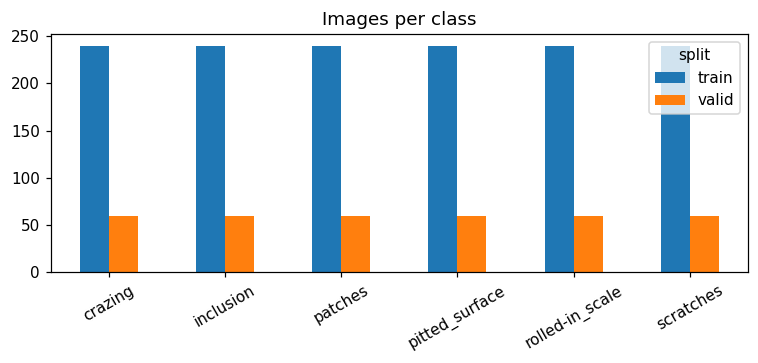

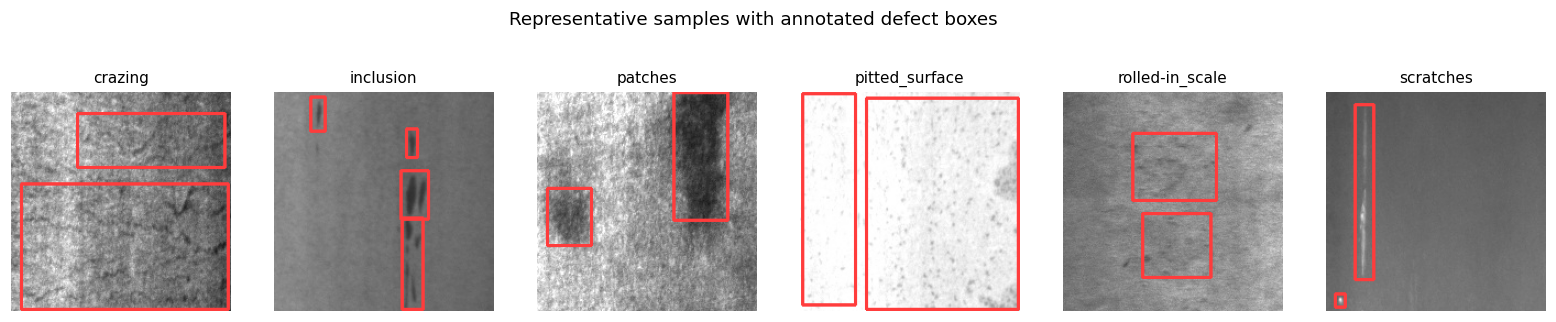

In [6]:
# class distribution + one sample per class (with the annotated box)
classes = sorted(df.cls.unique())
fig, ax = plt.subplots(figsize=(7, 3.4))
cnt = df.groupby(["cls", "split"]).size().unstack().reindex(classes)
cnt.plot.bar(ax=ax, rot=30); ax.set_title("Images per class"); ax.set_xlabel("")
fig.tight_layout(); plt.show()

fig, axs = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3.3))
for a, c in zip(np.atleast_1d(axs), classes):
    r = df[(df.cls == c) & (df.split == "train")].iloc[0]
    im = cv2.cvtColor(IMAGES[r.path], cv2.COLOR_GRAY2RGB)
    for (x1, y1, x2, y2) in BOXES.get(r.stem, []): cv2.rectangle(im, (x1, y1), (x2, y2), (255, 60, 60), 2)
    a.imshow(im); a.set_title(c, fontsize=10); a.axis("off")
plt.suptitle("Representative samples with annotated defect boxes", y=1.02); plt.show()

## 2. Preprocessing → binary dataset (Normal vs Defective)
* Grayscale (images are already single-channel; colour inputs are converted with `cv2.cvtColor`).
* Defective = 64×64 window centred on each annotated box, Normal = 64×64 defect-free window from the same image (no overlap with any box).
* Every sample is resized to a common **128×128** resolution (bicubic).
* The official **train / valid** split of the dataset is respected: `valid` is used as the final **test** set; model selection (HOG parameters, C) uses a validation set carved out of `train` *by image*, so patches of one steel image never appear on both sides.

train patches (5663, 128, 128)  (normal=2281, defective=3382)
test  patches (1334, 128, 128)  (normal=527, defective=807)
sub-train (4548, 128, 128) | validation (1115, 128, 128)


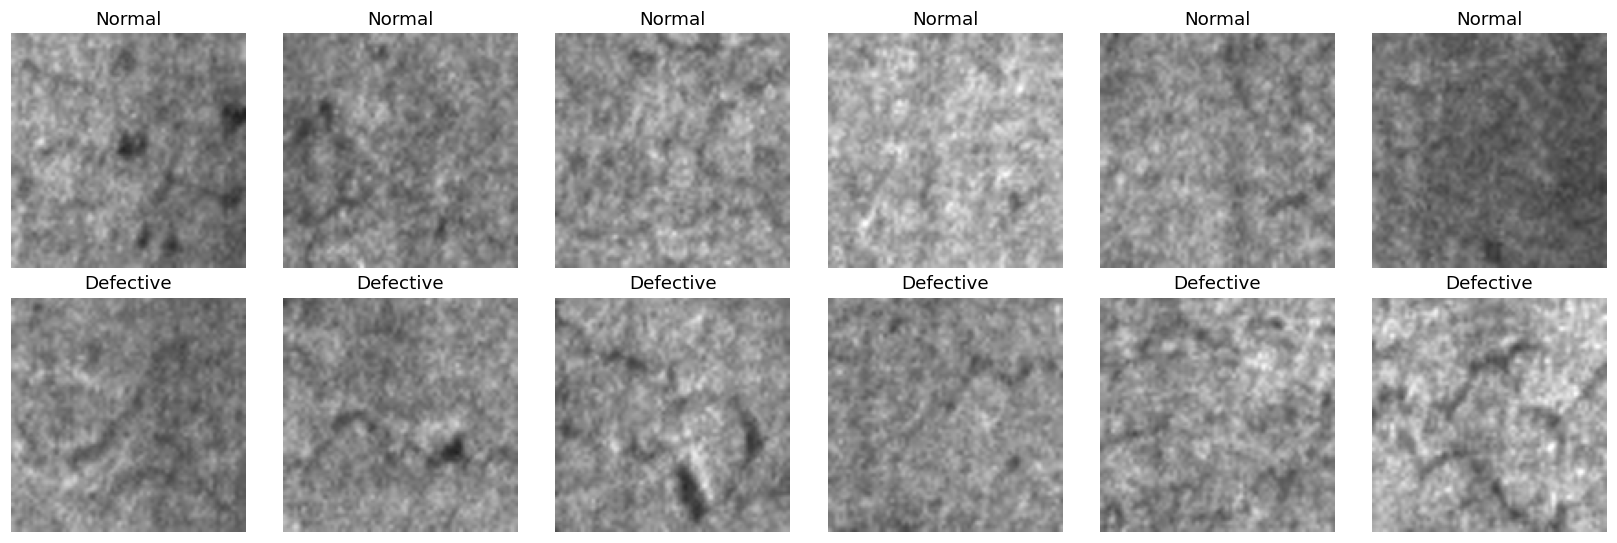

In [7]:
PATCH, SIZE = 64, 128
rng = np.random.default_rng(SEED)

def overlaps(x, y, boxes):
    return any(x < x2 and x + PATCH > x1 and y < y2 and y + PATCH > y1 for (x1, y1, x2, y2) in boxes)

def build_patches(sub):
    X, y, meta = [], [], []
    def add(crop, label, r, kind):
        X.append(cv2.resize(crop, (SIZE, SIZE), interpolation=cv2.INTER_CUBIC)); y.append(label)
        meta.append((r.stem, kind))
    for r in sub.itertuples():
        g = IMAGES[r.path]; H, W = g.shape; boxes = BOXES.get(r.stem, [])
        if not boxes or H < PATCH or W < PATCH: continue
        for (x1, y1, x2, y2) in boxes:
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
            x0 = int(np.clip(cx - PATCH // 2, 0, W - PATCH)); y0 = int(np.clip(cy - PATCH // 2, 0, H - PATCH))
            add(g[y0:y0 + PATCH, x0:x0 + PATCH], 1, r, r.cls)
            for _ in range(200):                      # one defect-free window per defect box (if the strip has room)
                x = int(rng.integers(0, W - PATCH + 1)); yy = int(rng.integers(0, H - PATCH + 1))
                if not overlaps(x, yy, boxes):
                    add(g[yy:yy + PATCH, x:x + PATCH], 0, r, "normal"); break
    return np.stack(X).astype(np.uint8), np.array(y), pd.DataFrame(meta, columns=["stem", "kind"])

assert HAS_BOXES, "No XML annotations were found: the binary Normal/Defective task needs them (see notes above)."
tr_df, te_df = df[df.split == "train"], df[df.split == "valid"]
Xtr_all, ytr_all, mtr_all = build_patches(tr_df)
Xte, yte, mte = build_patches(te_df)
print(f"train patches {Xtr_all.shape}  (normal={np.sum(ytr_all==0)}, defective={np.sum(ytr_all==1)})")
print(f"test  patches {Xte.shape}  (normal={np.sum(yte==0)}, defective={np.sum(yte==1)})")

# validation split grouped by source image
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
i_tr, i_va = next(gss.split(Xtr_all, ytr_all, groups=mtr_all.stem))
Xtr, ytr, Xva, yva = Xtr_all[i_tr], ytr_all[i_tr], Xtr_all[i_va], ytr_all[i_va]
print("sub-train", Xtr.shape, "| validation", Xva.shape)

fig, axs = plt.subplots(2, 6, figsize=(15, 5))
for k in range(6):
    axs[0, k].imshow(Xtr_all[ytr_all == 0][(k * 7) % max(1, np.sum(ytr_all == 0))], cmap="gray", vmin=0, vmax=255); axs[0, k].set_title("Normal"); axs[0, k].axis("off")
    axs[1, k].imshow(Xtr_all[ytr_all == 1][(k * 31) % max(1, np.sum(ytr_all == 1))], cmap="gray", vmin=0, vmax=255); axs[1, k].set_title("Defective"); axs[1, k].axis("off")
plt.tight_layout(); plt.show()

## 3. HOG feature extraction & visualisation

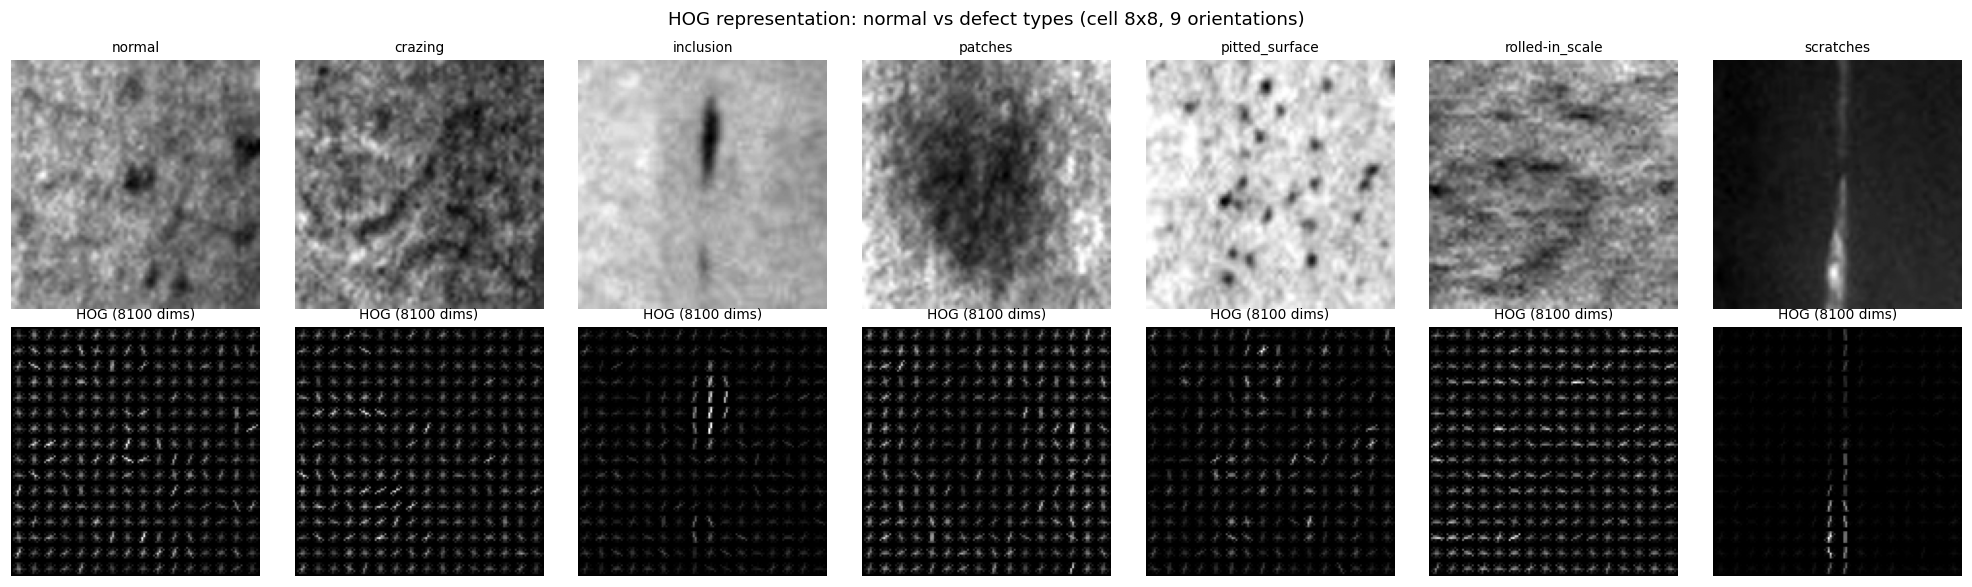

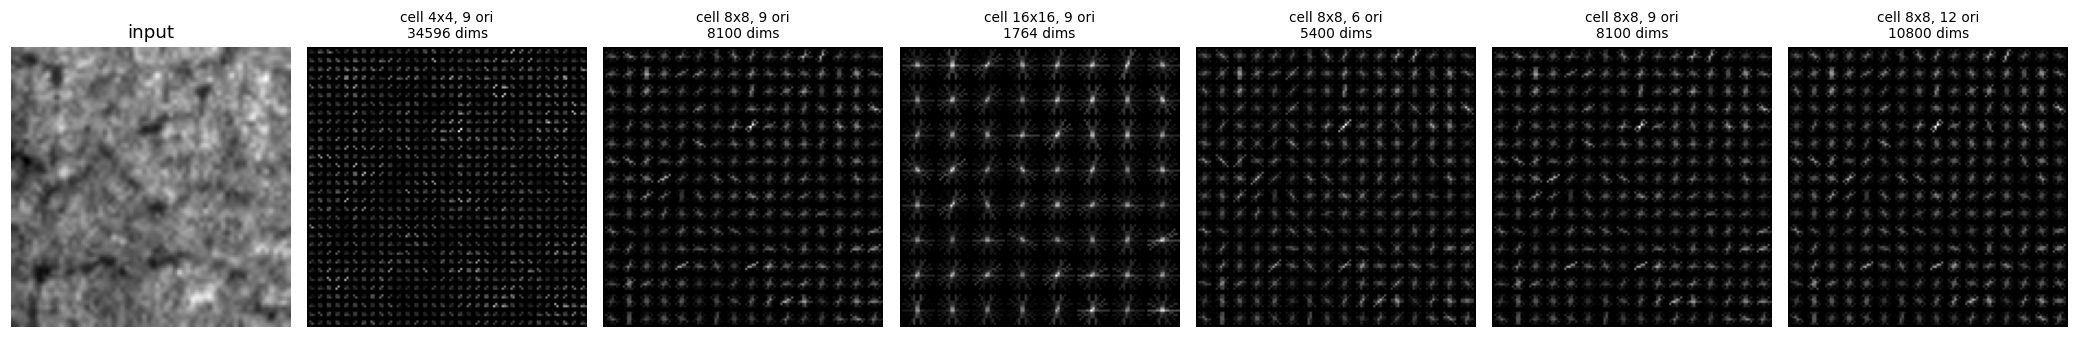

In [8]:
def hog_vis(img, cell=8, orient=9):
    f, v = sk_hog(img, orientations=orient, pixels_per_cell=(cell, cell), cells_per_block=(2, 2),
                  block_norm="L2-Hys", visualize=True, feature_vector=True)
    return exposure.rescale_intensity(v, in_range=(0, v.max() + 1e-9)), len(f)

# (a) Normal vs. defective patches (and one example per defect type), cell=8, 9 orientations
kinds = ["normal"] + [c for c in classes if c in set(mtr_all.kind)]
fig, axs = plt.subplots(2, len(kinds), figsize=(2.6 * len(kinds), 5.4))
for k, kd in enumerate(kinds):
    idx = np.where(mtr_all.kind.values == kd)[0][0]
    im = Xtr_all[idx]; v, n = hog_vis(im)
    axs[0, k].imshow(im, cmap="gray"); axs[0, k].set_title(kd, fontsize=9); axs[0, k].axis("off")
    axs[1, k].imshow(v, cmap="gray"); axs[1, k].set_title(f"HOG ({n} dims)", fontsize=9); axs[1, k].axis("off")
plt.suptitle("HOG representation: normal vs defect types (cell 8x8, 9 orientations)"); plt.tight_layout(); plt.show()

# (b) Effect of cell size and orientations on one defective patch
im = Xtr_all[np.where(ytr_all == 1)[0][5]]
fig, axs = plt.subplots(1, 7, figsize=(19, 3))
axs[0].imshow(im, cmap="gray"); axs[0].set_title("input"); axs[0].axis("off")
for a, c in zip(axs[1:4], (4, 8, 16)):
    v, n = hog_vis(im, cell=c, orient=9); a.imshow(v, cmap="gray"); a.set_title(f"cell {c}x{c}, 9 ori\n{n} dims", fontsize=9); a.axis("off")
for a, o in zip(axs[4:], (6, 9, 12)):
    v, n = hog_vis(im, cell=8, orient=o); a.imshow(v, cmap="gray"); a.set_title(f"cell 8x8, {o} ori\n{n} dims", fontsize=9); a.axis("off")
plt.tight_layout(); plt.show()

## 4. Required experiment: HOG cell size × orientations (HOG + SVM-RBF)
Cell sizes **4, 8, 16** × orientations **6, 9, 12** = 9 configurations. Selection is done on the **validation** split (not the test set).

,cell,orientations,dims,feat_time_s,fit_time_s,Accuracy,Precision,Recall,F1
0,4,6,23064,1.5606,1.9446,0.7274,0.7525,0.8048,0.7778
1,4,9,34596,2.1793,2.1831,0.7318,0.7479,0.8260,0.7850
2,4,12,46128,3.4445,2.1416,0.7094,0.7311,0.8064,0.7669
3,8,6,5400,0.3576,0.6531,0.7327,0.7582,0.8064,0.7815
4,8,9,8100,0.4459,0.6680,0.7704,0.7809,0.8517,0.8148
5,8,12,10800,0.5445,0.7153,0.7274,0.7554,0.7988,0.7765
6,16,6,1176,0.2310,0.7094,0.7399,0.7765,0.7882,0.7823
7,16,9,1764,0.2679,0.6364,0.7650,0.7921,0.8185,0.8051
8,16,12,2352,0.3009,0.6325,0.7516,0.7799,0.8094,0.7944


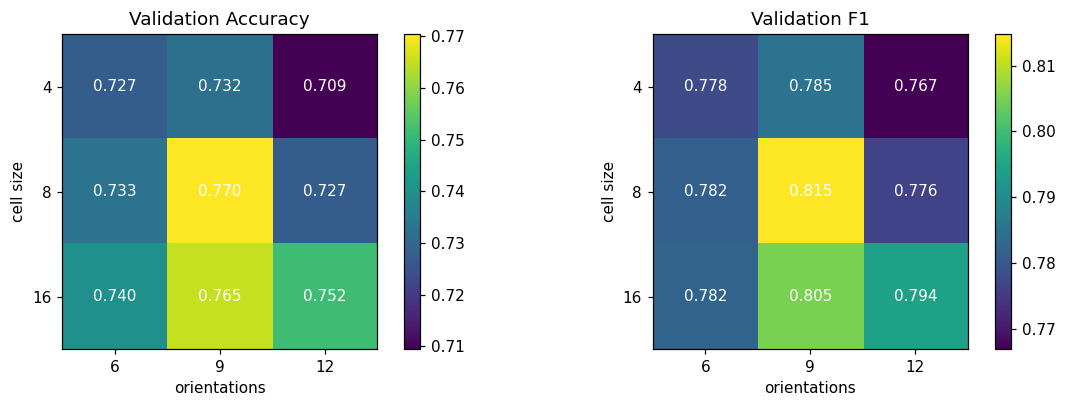


Best HOG config on validation: cell=8x8, orientations=9  (F1=0.8148)
Validation F1 vs C: {0.1: 0.5507, 1: 0.7814, 10: 0.8148, 100: 0.8148, 1000: 0.8148}
Chosen C = 10


In [9]:
def binary_metrics(y, p):
    return dict(Accuracy=accuracy_score(y, p), Precision=precision_score(y, p, zero_division=0),
                Recall=recall_score(y, p, zero_division=0), F1=f1_score(y, p, zero_division=0))

rows = []
for cell in (4, 8, 16):
    for ori in (6, 9, 12):
        t0 = time.perf_counter(); Ftr = hog_torch(Xtr, cell, ori); Fva = hog_torch(Xva, cell, ori)
        t_feat = time.perf_counter() - t0
        t0 = time.perf_counter(); m = KernelSVC("rbf", C=10).fit(Ftr, ytr); t_fit = time.perf_counter() - t0
        rows.append(dict(cell=cell, orientations=ori, dims=Ftr.shape[1], feat_time_s=t_feat, fit_time_s=t_fit,
                         **binary_metrics(yva, m.predict(Fva))))
        if DEVICE.type == "cuda": torch.cuda.empty_cache()
sweep = pd.DataFrame(rows)
display(sweep.round(4))
sweep.to_csv(OUT / "hog_parameter_sweep.csv", index=False)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for a, met in zip(axs, ("Accuracy", "F1")):
    pv = sweep.pivot(index="cell", columns="orientations", values=met)
    im_ = a.imshow(pv.values, cmap="viridis"); a.set_xticks(range(3)); a.set_xticklabels(pv.columns); a.set_yticks(range(3)); a.set_yticklabels(pv.index)
    a.set_xlabel("orientations"); a.set_ylabel("cell size"); a.set_title(f"Validation {met}")
    for i in range(3):
        for j in range(3): a.text(j, i, f"{pv.values[i, j]:.3f}", ha="center", va="center", color="w", fontsize=10)
    plt.colorbar(im_, ax=a, fraction=0.046)
plt.tight_layout(); plt.savefig(OUT / "hog_sweep_heatmap.png"); plt.show()

best = sweep.sort_values(["F1", "Accuracy"], ascending=False).iloc[0]   # ties -> smaller feature vector is fine; first row wins
BEST_CELL, BEST_ORI = int(best.cell), int(best.orientations)
print(f"\nBest HOG config on validation: cell={BEST_CELL}x{BEST_CELL}, orientations={BEST_ORI}  (F1={best.F1:.4f})")

# tune the SVM penalty C for that config (kernel is cheap on the GPU)
Ftr, Fva = hog_torch(Xtr, BEST_CELL, BEST_ORI), hog_torch(Xva, BEST_CELL, BEST_ORI)
cres = {C: f1_score(yva, KernelSVC("rbf", C=C).fit(Ftr, ytr).predict(Fva)) for C in (0.1, 1, 10, 100, 1000)}
print("Validation F1 vs C:", {k: round(v, 4) for k, v in cres.items()})
BEST_C = max(cres, key=cres.get); print("Chosen C =", BEST_C)

## 5. Final classifiers (HOG + SVM, HOG + Random Forest, HOG + XGBoost-GPU, HOG + kNN)
Trained on the full training split with the selected HOG configuration, evaluated once on the held-out **test** split (`valid` folder).

HOG feature matrix: (5663, 8100) (train) (1334, 8100) (test)


,Accuracy,Precision,Recall,F1,train_s,ms_per_sample
Model,,,,,,
HOG + SVM (RBF),0.7774,0.8043,0.8352,0.8195,3.5704,0.1352
HOG + SVM (linear),0.7106,0.7795,0.7274,0.7526,8.5946,0.1253
HOG + Random Forest,0.7579,0.7585,0.8798,0.8147,251.0200,0.2434
HOG + kNN (k=5),0.5157,0.9005,0.2243,0.3591,0.0265,1.0695
HOG + XGBoost (GPU),0.7639,0.7971,0.8178,0.8073,32.0698,0.1245


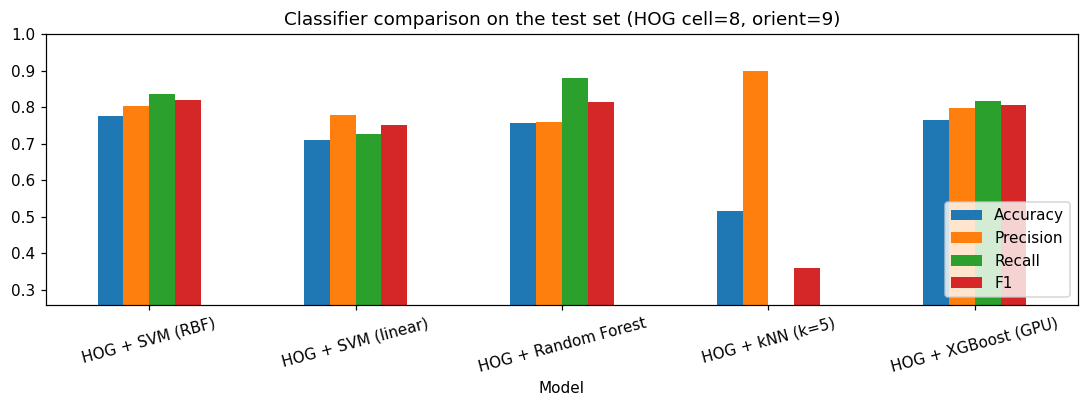

In [10]:
Ftr_full = hog_torch(Xtr_all, BEST_CELL, BEST_ORI)
Fte = hog_torch(Xte, BEST_CELL, BEST_ORI)
print("HOG feature matrix:", Ftr_full.shape, "(train)", Fte.shape, "(test)")

models = {
    "SVM (RBF)":    KernelSVC("rbf", C=BEST_C, probability=True),
    "SVM (linear)": KernelSVC("linear", C=BEST_C, probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, class_weight="balanced", random_state=SEED),
    "kNN (k=5)":    KNeighborsClassifier(n_neighbors=5, metric="cosine", n_jobs=-1),
}
try:
    import xgboost as xgb
    def make_xgb():
        return xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8, colsample_bytree=0.3,
                                 tree_method="hist", device="cuda" if DEVICE.type == "cuda" else "cpu", random_state=SEED)
    models["XGBoost (GPU)"] = make_xgb()
except ImportError:
    make_xgb = None; print("xgboost not installed -> skipped")

res_rows, preds = [], {}
for name, m in models.items():
    t0 = time.perf_counter(); m.fit(Ftr_full, ytr_all); t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); p = m.predict(Fte); t_pred = (time.perf_counter() - t0) / len(Fte) * 1000
    preds[name] = p
    res_rows.append(dict(Model="HOG + " + name, **binary_metrics(yte, p), train_s=t_fit, ms_per_sample=t_pred))
results = pd.DataFrame(res_rows).set_index("Model")
display(results.round(4)); results.to_csv(OUT / "classifier_comparison.csv")

ax = results[["Accuracy", "Precision", "Recall", "F1"]].plot.bar(figsize=(10, 3.8), rot=15, ylim=(max(0, results[["Accuracy","F1"]].min().min() - 0.1), 1.0))
ax.set_title("Classifier comparison on the test set (HOG cell=%d, orient=%d)" % (BEST_CELL, BEST_ORI)); ax.legend(loc="lower right"); plt.tight_layout(); plt.savefig(OUT / "classifier_comparison.png"); plt.show()

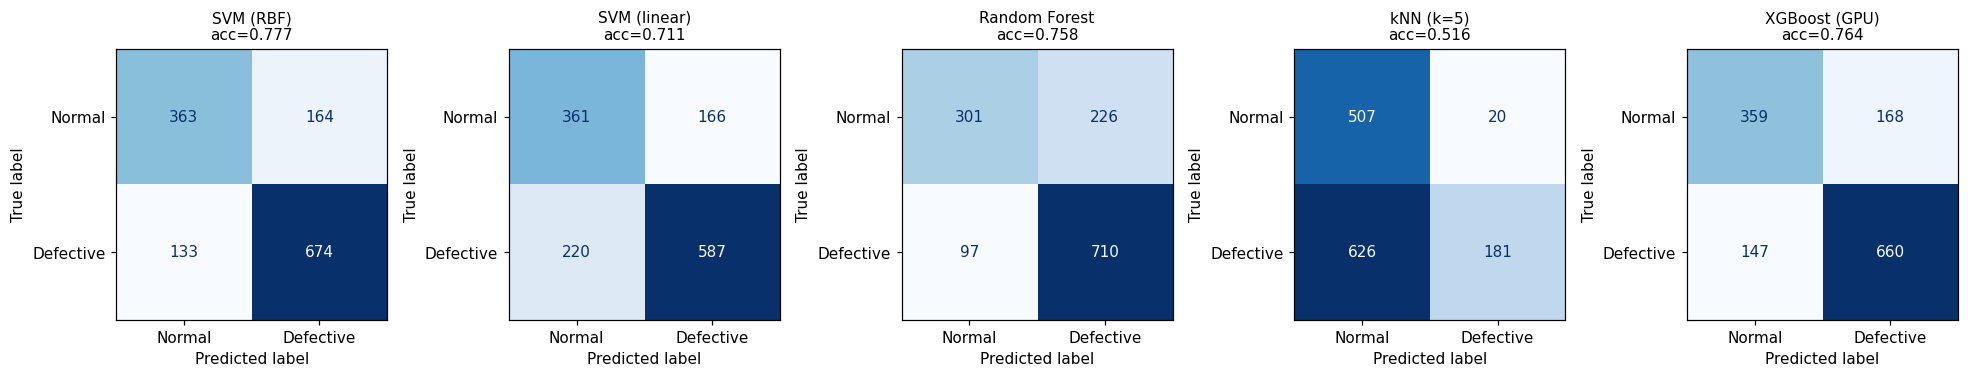


===== Classification report: HOG + SVM (RBF) =====
               precision    recall  f1-score   support

   Normal (0)     0.7319    0.6888    0.7097       527
Defective (1)     0.8043    0.8352    0.8195       807

     accuracy                         0.7774      1334
    macro avg     0.7681    0.7620    0.7646      1334
 weighted avg     0.7757    0.7774    0.7761      1334


===== Classification report: HOG + Random Forest =====
               precision    recall  f1-score   support

   Normal (0)     0.7563    0.5712    0.6508       527
Defective (1)     0.7585    0.8798    0.8147       807

     accuracy                         0.7579      1334
    macro avg     0.7574    0.7255    0.7327      1334
 weighted avg     0.7577    0.7579    0.7499      1334



In [11]:
# confusion matrices + classification reports
names = list(models)
fig, axs = plt.subplots(1, len(names), figsize=(3.6 * len(names), 3.4))
for a, n in zip(np.atleast_1d(axs), names):
    ConfusionMatrixDisplay(confusion_matrix(yte, preds[n]), display_labels=["Normal", "Defective"]).plot(ax=a, colorbar=False, cmap="Blues")
    a.set_title(f"{n}\nacc={accuracy_score(yte, preds[n]):.3f}", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "confusion_matrices.png"); plt.show()

for n in names[:1] + [m for m in names if m.startswith("Random")]:
    print(f"\n===== Classification report: HOG + {n} =====")
    print(classification_report(yte, preds[n], target_names=["Normal (0)", "Defective (1)"], digits=4))

## 6. Advanced: multi-class defect classification (6 NEU defect types, full images)
Same pipeline (grayscale → 128×128 → HOG with the selected parameters) applied to the *full* steel-surface images.

,Accuracy,Precision_macro,Recall_macro,F1_macro
Model,,,,
HOG + SVM (RBF),0.8389,0.8383,0.8389,0.8367
HOG + Random Forest,0.7694,0.7781,0.7694,0.7588
HOG + XGBoost (GPU),0.8028,0.8044,0.8028,0.7990


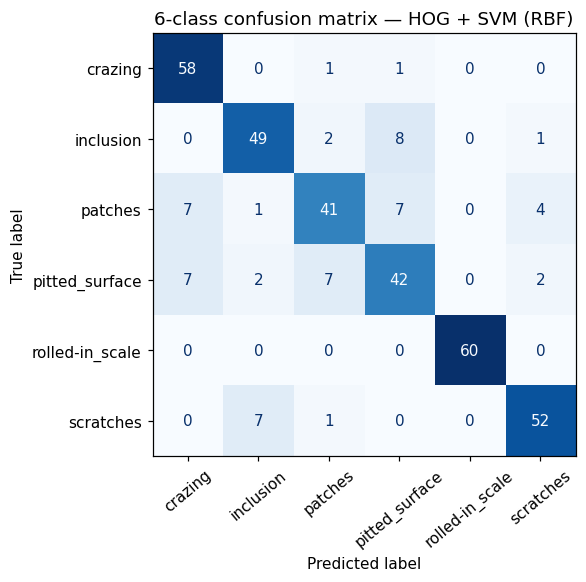

                 precision    recall  f1-score   support

        crazing     0.8056    0.9667    0.8788        60
      inclusion     0.8305    0.8167    0.8235        60
        patches     0.7885    0.6833    0.7321        60
 pitted_surface     0.7241    0.7000    0.7119        60
rolled-in_scale     1.0000    1.0000    1.0000        60
      scratches     0.8814    0.8667    0.8739        60

       accuracy                         0.8389       360
      macro avg     0.8383    0.8389    0.8367       360
   weighted avg     0.8383    0.8389    0.8367       360



In [12]:
def full_set(sub):
    X = np.stack([cv2.resize(IMAGES[p], (SIZE, SIZE), interpolation=cv2.INTER_AREA) for p in sub.path]); return X, sub.cls.values
Xm_tr, cm_tr = full_set(tr_df); Xm_te, cm_te = full_set(te_df)
le = LabelEncoder().fit(cm_tr); ym_tr, ym_te = le.transform(cm_tr), le.transform(cm_te)
Fm_tr, Fm_te = hog_torch(Xm_tr, BEST_CELL, BEST_ORI), hog_torch(Xm_te, BEST_CELL, BEST_ORI)

mc_models = {"SVM (RBF)": KernelSVC("rbf", C=BEST_C),
             "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED)}
if make_xgb is not None: mc_models["XGBoost (GPU)"] = make_xgb()
mc_rows, mc_pred = [], {}
for n, m in mc_models.items():
    m.fit(Fm_tr, ym_tr); p = m.predict(Fm_te); mc_pred[n] = p
    mc_rows.append(dict(Model="HOG + " + n, Accuracy=accuracy_score(ym_te, p),
                        Precision_macro=precision_score(ym_te, p, average="macro", zero_division=0),
                        Recall_macro=recall_score(ym_te, p, average="macro", zero_division=0),
                        F1_macro=f1_score(ym_te, p, average="macro", zero_division=0)))
mc_res = pd.DataFrame(mc_rows).set_index("Model"); display(mc_res.round(4)); mc_res.to_csv(OUT / "multiclass_results.csv")

best_mc = mc_res.F1_macro.idxmax().replace("HOG + ", "")
fig, ax = plt.subplots(figsize=(6.2, 5.4))
ConfusionMatrixDisplay(confusion_matrix(ym_te, mc_pred[best_mc]), display_labels=le.classes_).plot(ax=ax, cmap="Blues", xticks_rotation=40, colorbar=False)
ax.set_title(f"6-class confusion matrix — HOG + {best_mc}"); plt.tight_layout(); plt.savefig(OUT / "multiclass_confusion.png"); plt.show()
print(classification_report(ym_te, mc_pred[best_mc], target_names=le.classes_, digits=4))

## 7. Robustness analysis
The **trained** models are tested on perturbed copies of the *test patches* (the training data is not changed): brightness change, Gaussian noise, rotation and blur — 4 conditions × 3 severity levels. Perturbations run on the GPU.


=== Robustness: HOG + SVM (RBF) ===


,Condition,Level,Accuracy,F1,dAcc,dF1
0,Clean,-,0.7774,0.8195,0.0000,0.0000
1,Brightness,x0.5,0.7774,0.8195,0.0000,0.0000
2,Brightness,x0.75,0.7774,0.8195,0.0000,0.0000
3,Brightness,x1.5,0.7624,0.8169,-0.0150,-0.0026
4,Gaussian noise,sigma=10,0.4205,0.0874,-0.3568,-0.7321
5,Gaussian noise,sigma=25,0.3951,0.0000,-0.3823,-0.8195
6,Gaussian noise,sigma=50,0.3951,0.0000,-0.3823,-0.8195
7,Rotation,5 deg,0.6537,0.7678,-0.1237,-0.0516
8,Rotation,15 deg,0.6477,0.7673,-0.1297,-0.0521
9,Rotation,30 deg,0.6424,0.7640,-0.1349,-0.0555



=== Robustness: HOG + Random Forest ===


,Condition,Level,Accuracy,F1,dAcc,dF1
0,Clean,-,0.7579,0.8147,0.0000,0.0000
1,Brightness,x0.5,0.7579,0.8147,0.0000,0.0000
2,Brightness,x0.75,0.7579,0.8147,0.0000,0.0000
3,Brightness,x1.5,0.7451,0.8146,-0.0127,-0.0001
4,Gaussian noise,sigma=10,0.4340,0.1272,-0.3238,-0.6875
5,Gaussian noise,sigma=25,0.3951,0.0000,-0.3628,-0.8147
6,Gaussian noise,sigma=50,0.3951,0.0000,-0.3628,-0.8147
7,Rotation,5 deg,0.6649,0.7795,-0.0930,-0.0352
8,Rotation,15 deg,0.6529,0.7729,-0.1049,-0.0418
9,Rotation,30 deg,0.6432,0.7700,-0.1147,-0.0446


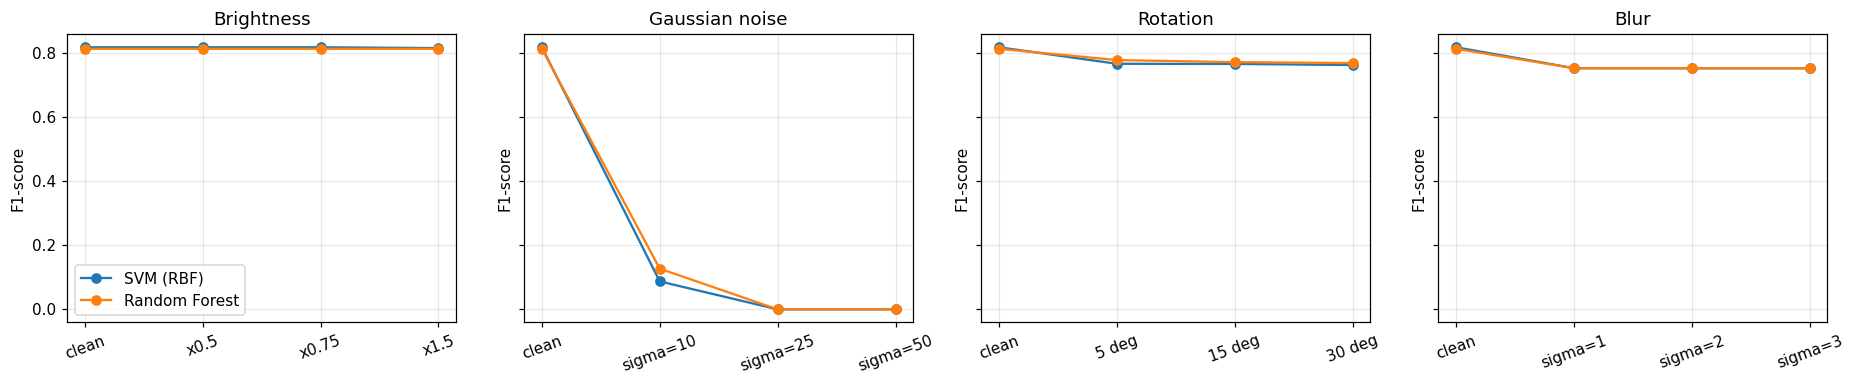

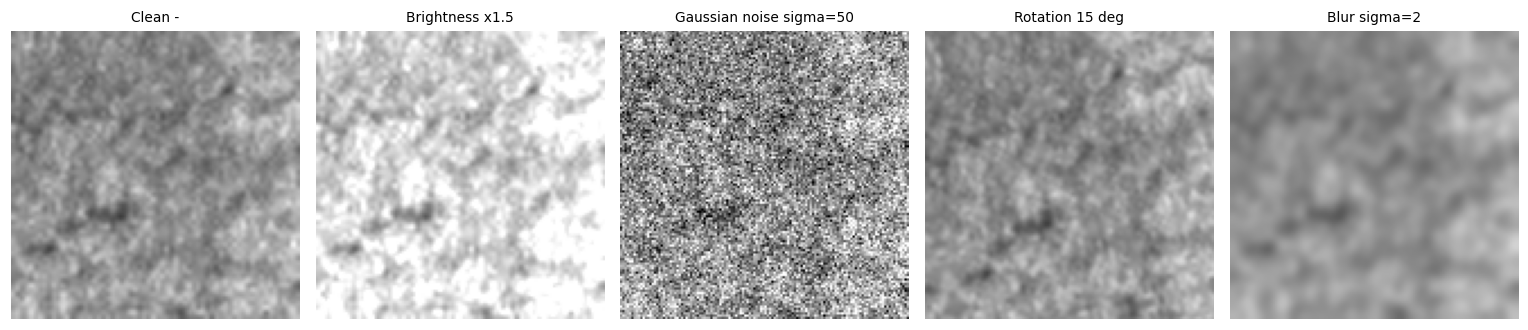

In [13]:
def p_brightness(x, f): return (x * f).clamp(0, 255)
def p_noise(x, s, seed=0):
    g = torch.Generator(device=x.device).manual_seed(seed)
    return (x + torch.randn(x.shape, generator=g, device=x.device) * s).clamp(0, 255)
def p_rotate(x, deg):
    N, H, W = x.shape; t = math.radians(deg)
    theta = torch.tensor([[math.cos(t), -math.sin(t), 0.], [math.sin(t), math.cos(t), 0.]], device=x.device).repeat(N, 1, 1)
    grid = F.affine_grid(theta, (N, 1, H, W), align_corners=False)
    return F.grid_sample(x[:, None], grid, mode="bilinear", padding_mode="reflection", align_corners=False)[:, 0]
def p_blur(x, sigma):
    k = int(2 * math.ceil(3 * sigma) + 1); ax_ = torch.arange(k, device=x.device).float() - k // 2
    g = torch.exp(-ax_ ** 2 / (2 * sigma ** 2)); g = g / g.sum(); ker = (g[:, None] * g[None, :])[None, None]
    return F.conv2d(F.pad(x[:, None], (k // 2,) * 4, mode="reflect"), ker)[:, 0]

CONDITIONS = [("Clean", "-", lambda x: x)]
CONDITIONS += [("Brightness", f"x{f}", partial(p_brightness, f=f)) for f in (0.5, 0.75, 1.5)]
CONDITIONS += [("Gaussian noise", f"sigma={s}", partial(p_noise, s=s)) for s in (10, 25, 50)]
CONDITIONS += [("Rotation", f"{d} deg", partial(p_rotate, deg=d)) for d in (5, 15, 30)]
CONDITIONS += [("Blur", f"sigma={s}", partial(p_blur, sigma=s)) for s in (1, 2, 3)]

Xte_t = torch.from_numpy(Xte).to(DEVICE).float()
FEAT_CACHE = {(g, l): hog_torch(fn(Xte_t), BEST_CELL, BEST_ORI) for g, l, fn in CONDITIONS}   # HOG of every perturbed test set (computed once)

def robustness_table(model):
    rows = []
    for (g, l), Fx in FEAT_CACHE.items():
        p = model.predict(Fx); rows.append(dict(Condition=g, Level=l, Accuracy=accuracy_score(yte, p), F1=f1_score(yte, p)))
    t = pd.DataFrame(rows); base = t.iloc[0]
    t["dAcc"] = t.Accuracy - base.Accuracy; t["dF1"] = t.F1 - base.F1
    return t

rob = {n: robustness_table(models[n]) for n in ("SVM (RBF)", "Random Forest")}
for n, t in rob.items():
    print(f"\n=== Robustness: HOG + {n} ==="); display(t.round(4)); t.to_csv(OUT / f"robustness_{n.split()[0].lower()}.csv", index=False)

fig, axs = plt.subplots(1, 4, figsize=(17, 3.6), sharey=True)
for a, grp in zip(axs, ("Brightness", "Gaussian noise", "Rotation", "Blur")):
    for n, t in rob.items():
        s = t[t.Condition == grp]; a.plot(["clean"] + list(s.Level), [t.F1.iloc[0]] + list(s.F1), marker="o", label=n)
    a.set_title(grp); a.set_ylabel("F1-score"); a.grid(alpha=.3); a.tick_params(axis="x", rotation=20)
axs[0].legend(); plt.tight_layout(); plt.savefig(OUT / "robustness_f1.png"); plt.show()

# example perturbed patches
fig, axs = plt.subplots(1, 5, figsize=(14, 3))
ex = Xte_t[[int(np.where(yte == 1)[0][3])]]
for a, (g, l, fn) in zip(axs, [CONDITIONS[0], CONDITIONS[3], CONDITIONS[6], CONDITIONS[8], CONDITIONS[11]]):
    a.imshow(fn(ex)[0].cpu(), cmap="gray", vmin=0, vmax=255); a.set_title(f"{g} {l}", fontsize=9); a.axis("off")
plt.tight_layout(); plt.show()

### 7b. Can augmentation fix the weak spots?
The SVM is re-trained with (a) the original training patches plus (b) perturbed copies (a random quarter of the training set for each of 8 perturbations: brightness ×0.7/×1.3, noise σ=15/30, rotation ±10°, blur σ=1/1.5). The test set is unchanged.

augmented training set: (16983, 8100)


,Condition,Level,Accuracy_base,F1_base,Accuracy_aug,F1_aug
0,Clean,-,0.7774,0.8195,0.7196,0.7700
1,Brightness,x0.5,0.7774,0.8195,0.7196,0.7700
2,Brightness,x0.75,0.7774,0.8195,0.7196,0.7700
3,Brightness,x1.5,0.7624,0.8169,0.6844,0.7387
4,Gaussian noise,sigma=10,0.4205,0.0874,0.5652,0.6343
5,Gaussian noise,sigma=25,0.3951,0.0000,0.5307,0.5892
6,Gaussian noise,sigma=50,0.3951,0.0000,0.5300,0.5778
7,Rotation,5 deg,0.6537,0.7678,0.6694,0.7373
8,Rotation,15 deg,0.6477,0.7673,0.6499,0.7324
9,Rotation,30 deg,0.6424,0.7640,0.6349,0.7231


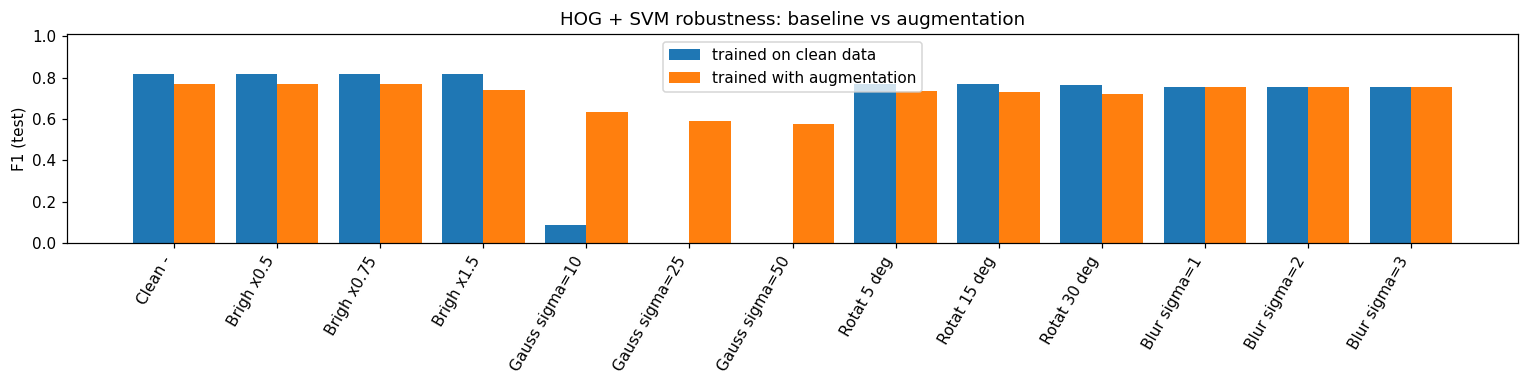

In [14]:
Xtr_t = torch.from_numpy(Xtr_all).to(DEVICE).float()
AUGS = [partial(p_brightness, f=0.7), partial(p_brightness, f=1.3), partial(p_noise, s=15), partial(p_noise, s=30),
        partial(p_rotate, deg=10), partial(p_rotate, deg=-10), partial(p_blur, sigma=1.0), partial(p_blur, sigma=1.5)]
F_aug, y_aug = [Ftr_full], [ytr_all]
for fn in AUGS:
    idx = rng.permutation(len(Xtr_t))[: len(Xtr_t) // 4]
    F_aug.append(hog_torch(fn(Xtr_t[torch.from_numpy(idx).to(DEVICE)]), BEST_CELL, BEST_ORI)); y_aug.append(ytr_all[idx])
F_aug, y_aug = np.concatenate(F_aug), np.concatenate(y_aug)
print("augmented training set:", F_aug.shape)

svm_aug = KernelSVC("rbf", C=BEST_C).fit(F_aug, y_aug)
t_aug = robustness_table(svm_aug)
cmp_ = rob["SVM (RBF)"][["Condition", "Level", "Accuracy", "F1"]].merge(t_aug[["Condition", "Level", "Accuracy", "F1"]], on=["Condition", "Level"], suffixes=("_base", "_aug"))
display(cmp_.round(4)); cmp_.to_csv(OUT / "robustness_augmentation.csv", index=False)

lab = [f"{g[:5]} {l}" for g, l in zip(cmp_.Condition, cmp_.Level)]
x_ = np.arange(len(cmp_)); plt.figure(figsize=(14, 3.6))
plt.bar(x_ - .2, cmp_.F1_base, .4, label="trained on clean data"); plt.bar(x_ + .2, cmp_.F1_aug, .4, label="trained with augmentation")
plt.xticks(x_, lab, rotation=60, ha="right"); plt.ylabel("F1 (test)"); plt.ylim(max(0, cmp_[["F1_base", "F1_aug"]].min().min() - .05), 1.01); plt.legend(); plt.title("HOG + SVM robustness: baseline vs augmentation")
plt.tight_layout(); plt.savefig(OUT / "robustness_augmentation.png"); plt.show()

## 8. Industrial quality-control decision module
`inspect_product()` takes a product image:
* a **full strip image** is scanned with 64×64 sliding windows (stride 32 → 36 windows for a 200×200 image); each window is resized to 128×128 → HOG → SVM probability;
* the product is **REJECTED** if at least `min_windows` (=2) windows have defect probability ≥ `thr` (=0.5), otherwise **ACCEPTED**;
* an image that is already a single 128×128 patch is classified directly.

Confidence = mean defect probability of the flagged windows (reject) or 1 − mean of the 3 highest window scores (accept). `thr` and `min_windows` are the knobs a factory would tune to trade false rejects against missed defects.

--- input: full image: crazing
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 67.5%
Action: REJECT PRODUCT

--- input: full image: patches
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 66.5%
Action: REJECT PRODUCT

--- input: full image: rolled-in_scale
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 60.6%
Action: REJECT PRODUCT

--- input: normal patch
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 81.2%
Action: REJECT PRODUCT

--- input: normal patch
PRODUCT INSPECTION RESULT
Prediction: NON-DEFECTIVE
Confidence: 68.5%
Action: ACCEPT PRODUCT

--- input: normal patch
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 56.3%
Action: REJECT PRODUCT



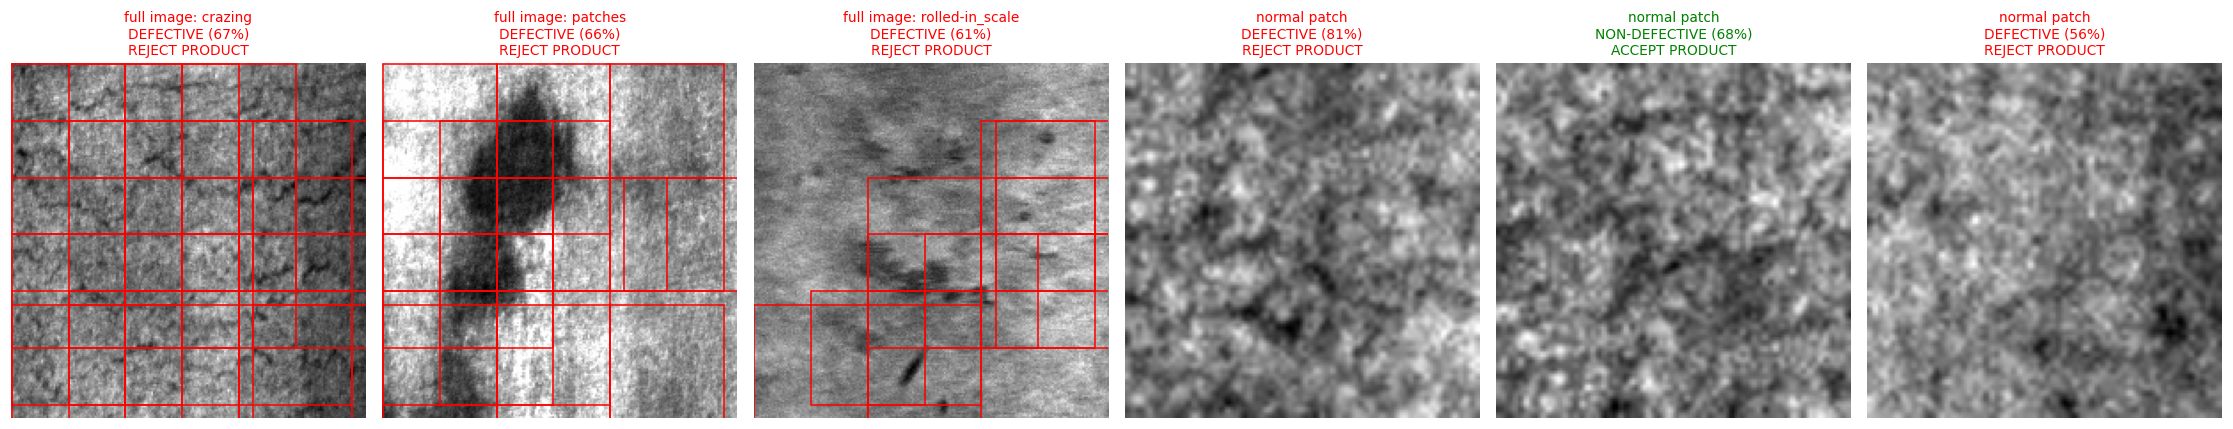

In [15]:
svm_final = models["SVM (RBF)"]
bundle = dict(model=svm_final, cell=BEST_CELL, orient=BEST_ORI, size=SIZE, patch=PATCH, thr=0.5, min_windows=2)
joblib.dump(bundle, "hog_defect_model.joblib")

# demo: 3 full defective images (different classes) + 3 normal patches from the test split
demo_defect = [te_df[te_df.cls == c].iloc[0] for c in classes[:6:2]] if len(classes) >= 6 else [te_df.iloc[0]]
demo_items = [(IMAGES[r.path], f"full image: {r.cls}") for r in demo_defect]
demo_items += [(Xte[i], "normal patch") for i in np.where(yte == 0)[0][:3]]

fig, axs = plt.subplots(1, len(demo_items), figsize=(3.4 * len(demo_items), 3.8))
for a, (im, title) in zip(np.atleast_1d(axs), demo_items):
    res = inspect_product(im, bundle)
    print(f"--- input: {title}"); print_report(res); print()
    a.imshow(im, cmap="gray"); a.axis("off")
    for (x, y, w, h), flag in zip(res["coords"], res["positive"]):
        if flag and len(res["coords"]) > 1: a.add_patch(plt.Rectangle((x, y), w, h, fill=False, ec="red", lw=1))
    a.set_title(f"{title}\n{res['prediction']} ({res['confidence']*100:.0f}%)\n{res['action']}", fontsize=9, color="red" if res["defective"] else "green")
plt.tight_layout(); plt.savefig(OUT / "decision_module_demo.png"); plt.show()

In [16]:
# system-level evaluation of the decision module
t0 = time.perf_counter()
full_res = [inspect_product(IMAGES[p], bundle) for p in te_df.path]
ms_full = (time.perf_counter() - t0) / len(full_res) * 1000
rej_full = np.mean([r["defective"] for r in full_res])
normal_res = [inspect_product(Xte[i], bundle) for i in np.where(yte == 0)[0]]
defect_res = [inspect_product(Xte[i], bundle) for i in np.where(yte == 1)[0]]
print(f"Full defective strip images rejected : {rej_full*100:.1f}%  ({len(full_res)} images, {ms_full:.1f} ms/image incl. 36 windows)")
print(f"Defect-free patches wrongly rejected : {np.mean([r['defective'] for r in normal_res])*100:.1f}%   (false-reject rate)")
print(f"Defective patches wrongly accepted   : {np.mean([not r['defective'] for r in defect_res])*100:.1f}%   (escape rate)")
pd.DataFrame(dict(reject_rate_full_images=[rej_full], false_reject_rate=[np.mean([r['defective'] for r in normal_res])],
                  escape_rate=[np.mean([not r['defective'] for r in defect_res])], ms_per_full_image=[ms_full])).to_csv(OUT / "decision_module_eval.csv", index=False)

Full defective strip images rejected : 100.0%  (360 images, 50.4 ms/image incl. 36 windows)
Defect-free patches wrongly rejected : 33.2%   (false-reject rate)
Defective patches wrongly accepted   : 15.5%   (escape rate)


Processing speed: 19.8 frames/s (full pipeline, incl. 36 windows per frame)


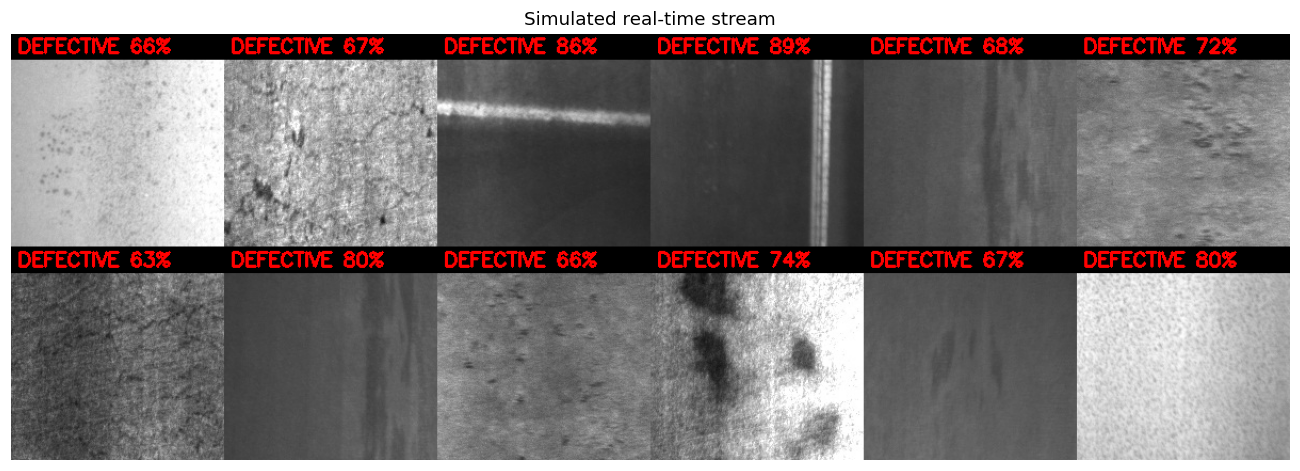

In [17]:
# A) simulated stream: 12 random full-size frames (defective strips), per-frame HOG + decision
sel = te_df.sample(12, random_state=SEED)
frames, t0 = [], time.perf_counter()
for r in sel.itertuples():
    res = inspect_product(IMAGES[r.path], bundle)
    f = cv2.cvtColor(IMAGES[r.path], cv2.COLOR_GRAY2BGR)
    label = "DEFECTIVE" if res["defective"] else "PASS"
    col = (0, 0, 255) if res["defective"] else (0, 200, 0)
    cv2.rectangle(f, (0, 0), (199, 24), (0, 0, 0), -1); cv2.putText(f, f"{label} {res['confidence']*100:.0f}%", (6, 18), cv2.FONT_HERSHEY_SIMPLEX, .6, col, 2)
    frames.append(f)
fps = len(frames) / (time.perf_counter() - t0); print(f"Processing speed: {fps:.1f} frames/s (full pipeline, incl. 36 windows per frame)")
grid = np.vstack([np.hstack(frames[i:i + 6]) for i in (0, 6)])
plt.figure(figsize=(15, 5.2)); plt.imshow(cv2.cvtColor(grid, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.title("Simulated real-time stream"); plt.show()

### 9. Summary of results (copy these numbers/figures into the report)

In [19]:
print("HOG parameter sweep (validation):"); display(sweep.round(4))
print(f"\nSelected config: cell {BEST_CELL}x{BEST_CELL}, {BEST_ORI} orientations, SVM C={BEST_C}")
print("\nBinary classifiers (test):"); display(results.round(4))
print("\n6-class results (test):"); display(mc_res.round(4))
worst = rob["SVM (RBF)"].sort_values("dF1").iloc[0]
print(f"\nLargest SVM F1 drop under perturbation: {worst.Condition} {worst.Level}: dF1 = {worst.dF1:+.4f}")
print("\nSaved files:"); [print("  ", p) for p in sorted(map(str, OUT.glob("*")))]
print("   hog_utils.py, hog_defect_model.joblib, realtime_inspector.py")
try:
    from google.colab import files
    import shutil; shutil.make_archive("lab05_outputs", "zip", OUT); files.download("lab05_outputs.zip")
except Exception: pass

HOG parameter sweep (validation):


,cell,orientations,dims,feat_time_s,fit_time_s,Accuracy,Precision,Recall,F1
0,4,6,23064,1.5606,1.9446,0.7274,0.7525,0.8048,0.7778
1,4,9,34596,2.1793,2.1831,0.7318,0.7479,0.8260,0.7850
2,4,12,46128,3.4445,2.1416,0.7094,0.7311,0.8064,0.7669
3,8,6,5400,0.3576,0.6531,0.7327,0.7582,0.8064,0.7815
4,8,9,8100,0.4459,0.6680,0.7704,0.7809,0.8517,0.8148
5,8,12,10800,0.5445,0.7153,0.7274,0.7554,0.7988,0.7765
6,16,6,1176,0.2310,0.7094,0.7399,0.7765,0.7882,0.7823
7,16,9,1764,0.2679,0.6364,0.7650,0.7921,0.8185,0.8051
8,16,12,2352,0.3009,0.6325,0.7516,0.7799,0.8094,0.7944



Selected config: cell 8x8, 9 orientations, SVM C=10

Binary classifiers (test):


,Accuracy,Precision,Recall,F1,train_s,ms_per_sample
Model,,,,,,
HOG + SVM (RBF),0.7774,0.8043,0.8352,0.8195,3.5704,0.1352
HOG + SVM (linear),0.7106,0.7795,0.7274,0.7526,8.5946,0.1253
HOG + Random Forest,0.7579,0.7585,0.8798,0.8147,251.0200,0.2434
HOG + kNN (k=5),0.5157,0.9005,0.2243,0.3591,0.0265,1.0695
HOG + XGBoost (GPU),0.7639,0.7971,0.8178,0.8073,32.0698,0.1245



6-class results (test):


,Accuracy,Precision_macro,Recall_macro,F1_macro
Model,,,,
HOG + SVM (RBF),0.8389,0.8383,0.8389,0.8367
HOG + Random Forest,0.7694,0.7781,0.7694,0.7588
HOG + XGBoost (GPU),0.8028,0.8044,0.8028,0.7990



Largest SVM F1 drop under perturbation: Gaussian noise sigma=50: dF1 = -0.8195

Saved files:
   lab05_outputs/classifier_comparison.csv
   lab05_outputs/classifier_comparison.png
   lab05_outputs/confusion_matrices.png
   lab05_outputs/decision_module_demo.png
   lab05_outputs/decision_module_eval.csv
   lab05_outputs/hog_parameter_sweep.csv
   lab05_outputs/hog_sweep_heatmap.png
   lab05_outputs/multiclass_confusion.png
   lab05_outputs/multiclass_results.csv
   lab05_outputs/robustness_augmentation.csv
   lab05_outputs/robustness_augmentation.png
   lab05_outputs/robustness_f1.png
   lab05_outputs/robustness_random.csv
   lab05_outputs/robustness_svm.csv
   hog_utils.py, hog_defect_model.joblib, realtime_inspector.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>